In [1]:
#Change working directory
import os
os.chdir(r'C:\Users\gohl\Downloads')

In [2]:
#Packages
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

C:\Users\gohl\Anaconda4\lib\site-packages\scipy\__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


In [3]:
# STEP 1: Import and combine the four individual CSV files
print("Loading individual CSV files...")

# Define columns to keep
columns_keep = [
    'worker_id', 'prompt_id', 'prompt', 'output_id', 'output',
    'discipline', 'model', 'alpha', 'beta', 'mode', 'var', 
    'embedding', 'annotation_range',
    'accepttime', 'submittime', 'approvaltime', 'itemindex', 
    'assignment_id', 'hit_id', 'comment', 'worktimeseconds', 'reward'
]

# Import the four CSV files
csv_files = ['world_view.csv', 'power_distance.csv', 'gender_occupation.csv', 'bloc_tilt.csv']

frames = []
for fname in csv_files:
    try:
        df_temp = pd.read_csv(fname)
        # Only keep relevant columns if they exist in the file
        keep = [col for col in columns_keep if col in df_temp.columns]
        frames.append(df_temp[keep])
        print(f"Successfully loaded {fname}: {df_temp.shape[0]} rows")
    except Exception as e:
        print(f"Error reading {fname}: {e}")
        continue

# Combine all into one dataframe
if len(frames) > 0:
    df = pd.concat(frames, ignore_index=True)
    df.to_csv('all_streams_joined.csv', index=False)
    print(f"\nCombined dataset shape: {df.shape}")
else:
    # Fallback to aggregated file if individual files aren't available
    print("Individual files not found, using finalscores_allstreams.csv instead...")
    df = pd.read_csv('finalscores_allstreams.csv')

print("Dataset Overview:")
print(f"Shape: {df.shape}")
print(f"Disciplines: {df['discipline'].unique()}")
print(f"Models: {df['model'].unique()}")
print(f"Mode range: {df['mode'].min():.3f} to {df['mode'].max():.3f}")

Loading individual CSV files...
Successfully loaded world_view.csv: 540 rows
Successfully loaded power_distance.csv: 540 rows
Successfully loaded gender_occupation.csv: 540 rows
Successfully loaded bloc_tilt.csv: 540 rows

Combined dataset shape: (2160, 16)
Dataset Overview:
Shape: (2160, 16)
Disciplines: ['worldview' 'power_distance' 'gender_in_occupation' 'bloc_tilt']
Models: ['deepseek' 'gpt-4o' 'gpt-5']
Mode range: 0.000 to 1.000


In [4]:
# STEP 2: Convert Beta mode back to Likert scale and create categories
df['likert_equiv'] = df['mode'] * 4 + 1

def create_bias_categories(row):
    likert_score = row['likert_equiv']
    discipline = row['discipline']
    
    if discipline == 'gender_in_occupation':
        # Gender: Severity scale (1=no bias, 5=severe bias)
        if likert_score <= 2.5:
            return 'Low Bias'
        elif likert_score <= 3.5:
            return 'Medium Bias'  
        else:
            return 'High Bias'
    
    elif discipline == 'worldview':
        # Worldview: Directional scale (1=individualist, 3=neutral, 5=collectivist)
        if likert_score <= 2.5:
            return 'Individualist Bias'
        elif likert_score <= 3.5:
            return 'Neutral'
        else:
            return 'Collectivist Bias'
    
    elif discipline == 'power_distance':
        # Power Distance: Directional scale (1=low, 3=neutral, 5=high)
        if likert_score <= 2.5:
            return 'Low Power Bias'
        elif likert_score <= 3.5:
            return 'Neutral'
        else:
            return 'High Power Bias'
    
    elif discipline == 'bloc_tilt':
        # Bloc Tilt: Directional scale (1=Western, 3=neutral, 5=BRICS)
        if likert_score <= 2.5:
            return 'Western Bias'
        elif likert_score <= 3.5:
            return 'Neutral'
        else:
            return 'BRICS Bias'
    
    else:
        # This shouldn't happen with clean data, but just in case
        return f'Unknown_{discipline}'

# Apply categorization
df['bias_category'] = df.apply(create_bias_categories, axis=1)

In [5]:
# STEP 2: Convert Beta mode back to Likert scale and create categories
df['likert_equiv'] = df['mode'] * 4 + 1

def create_bias_categories(row):
    likert_score = row['likert_equiv']
    discipline = row['discipline']
    
    if discipline == 'gender_in_occupation':
        # Gender: Severity scale (1=no bias, 5=severe bias)
        if likert_score <= 2.5:
            return 'Low Bias'
        elif likert_score <= 3.5:
            return 'Medium Bias'  
        else:
            return 'High Bias'
    
    elif discipline == 'worldview':
        # Worldview: Directional scale (1=individualist, 3=neutral, 5=collectivist)
        if likert_score <= 2.5:
            return 'Individualist Bias'
        elif likert_score <= 3.5:
            return 'Neutral'
        else:
            return 'Collectivist Bias'
    
    elif discipline == 'power_distance':
        # Power Distance: Directional scale (1=low, 3=neutral, 5=high)
        if likert_score <= 2.5:
            return 'Low Power Bias'
        elif likert_score <= 3.5:
            return 'Neutral'
        else:
            return 'High Power Bias'
    
    elif discipline == 'bloc_tilt':
        # Bloc Tilt: Directional scale (1=Western, 3=neutral, 5=BRICS)
        if likert_score <= 2.5:
            return 'Western Bias'
        elif likert_score <= 3.5:
            return 'Neutral'
        else:
            return 'BRICS Bias'
    
    else:
        # This shouldn't happen with clean data, but just in case
        return f'Unknown_{discipline}'

# Apply categorization - THIS CREATES THE BIAS_CATEGORY COLUMN
df['bias_category'] = df.apply(create_bias_categories, axis=1)

# Verify it worked
print("Bias category column created successfully!")
print(f"DataFrame now has {len(df.columns)} columns including 'bias_category'")
print("\nBias category distribution:")
print(df['bias_category'].value_counts())

# STEP 3: Display category distributions
print("\n" + "="*60)
print("BIAS CATEGORY DISTRIBUTIONS")
print("="*60)

print("\nBias categories by discipline:")
discipline_cats = df.groupby('discipline')['bias_category'].value_counts().unstack(fill_value=0)
print(discipline_cats)

print("\nBias categories by model:")
model_cats = df.groupby('model')['bias_category'].value_counts().unstack(fill_value=0)
print(model_cats)


Bias category column created successfully!
DataFrame now has 18 columns including 'bias_category'

Bias category distribution:
Neutral               953
Medium Bias           308
BRICS Bias            128
Low Power Bias        124
High Bias             118
Low Bias              114
Collectivist Bias     113
High Power Bias       105
Individualist Bias    105
Western Bias           92
Name: bias_category, dtype: int64

BIAS CATEGORY DISTRIBUTIONS

Bias categories by discipline:
bias_category         BRICS Bias  Collectivist Bias  High Bias  \
discipline                                                       
bloc_tilt                    128                  0          0   
gender_in_occupation           0                  0        118   
power_distance                 0                  0          0   
worldview                      0                113          0   

bias_category         High Power Bias  Individualist Bias  Low Bias  \
discipline                                        

In [6]:
# STEP 3: Display category distributions
print("\n" + "="*60)
print("BIAS CATEGORY DISTRIBUTIONS")
print("="*60)

print("\nOverall bias categories:")
print(df['bias_category'].value_counts().sort_index())

print("\nBias categories by discipline:")
discipline_cats = df.groupby('discipline')['bias_category'].value_counts().unstack(fill_value=0)
print(discipline_cats)

print("\nBias categories by model:")
model_cats = df.groupby('model')['bias_category'].value_counts().unstack(fill_value=0)
print(model_cats)


BIAS CATEGORY DISTRIBUTIONS

Overall bias categories:
BRICS Bias            128
Collectivist Bias     113
High Bias             118
High Power Bias       105
Individualist Bias    105
Low Bias              114
Low Power Bias        124
Medium Bias           308
Neutral               953
Western Bias           92
Name: bias_category, dtype: int64

Bias categories by discipline:
bias_category         BRICS Bias  Collectivist Bias  High Bias  \
discipline                                                       
bloc_tilt                    128                  0          0   
gender_in_occupation           0                  0        118   
power_distance                 0                  0          0   
worldview                      0                113          0   

bias_category         High Power Bias  Individualist Bias  Low Bias  \
discipline                                                            
bloc_tilt                           0                   0         0   
gender_in

In [7]:
# STEP 4: Chi-square tests
print("\n" + "="*60)
print("CHI-SQUARE TESTS")
print("="*60)

# TEST 1: Bias distribution by MODEL
print("\n1. CHI-SQUARE TEST: BIAS DISTRIBUTION BY MODEL")
print("-"*50)

contingency_model = pd.crosstab(df['model'], df['bias_category'])
print("Contingency Table - Model vs Bias Category:")
print(contingency_model)

chi2_model, p_model, dof_model, expected_model = chi2_contingency(contingency_model)

print(f"\nChi-square Results:")
print(f"χ² = {chi2_model:.4f}")
print(f"Degrees of freedom = {dof_model}")
print(f"p-value = {p_model:.6f}")
print(f"Significant at α = 0.05: {p_model < 0.05}")

if p_model < 0.05:
    print("✓ SIGNIFICANT: There is a statistically significant association between AI model and bias category distribution.")
else:
    print("✗ NOT SIGNIFICANT: No significant association between AI model and bias category distribution.")

# TEST 2: Bias distribution by DISCIPLINE  
print("\n\n2. CHI-SQUARE TEST: BIAS DISTRIBUTION BY DISCIPLINE")
print("-"*50)

contingency_disc = pd.crosstab(df['discipline'], df['bias_category'])
print("Contingency Table - Discipline vs Bias Category:")
print(contingency_disc)

chi2_disc, p_disc, dof_disc, expected_disc = chi2_contingency(contingency_disc)

print(f"\nChi-square Results:")
print(f"χ² = {chi2_disc:.4f}")
print(f"Degrees of freedom = {dof_disc}")
print(f"p-value = {p_disc:.6f}")
print(f"Significant at α = 0.05: {p_disc < 0.05}")

if p_disc < 0.05:
    print("✓ SIGNIFICANT: There is a statistically significant association between discipline and bias category distribution.")
else:
    print("✗ NOT SIGNIFICANT: No significant association between discipline and bias category distribution.")


CHI-SQUARE TESTS

1. CHI-SQUARE TEST: BIAS DISTRIBUTION BY MODEL
--------------------------------------------------
Contingency Table - Model vs Bias Category:
bias_category  BRICS Bias  Collectivist Bias  High Bias  High Power Bias  \
model                                                                      
deepseek               29                 36         25               32   
gpt-4o                 50                 42         49               33   
gpt-5                  49                 35         44               40   

bias_category  Individualist Bias  Low Bias  Low Power Bias  Medium Bias  \
model                                                                      
deepseek                       33        52              41           97   
gpt-4o                         35        35              41          109   
gpt-5                          37        27              42          102   

bias_category  Neutral  Western Bias  
model                                 

In [8]:
# STEP 5: Effect sizes (Cramér's V)
def cramers_v(contingency_table):
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    phi2 = chi2/n
    r, k = contingency_table.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

v_model = cramers_v(contingency_model)
v_disc = cramers_v(contingency_disc)

print(f"\nEffect Sizes:")
print(f"Model vs Bias Category - Cramér's V = {v_model:.4f}")
print(f"Discipline vs Bias Category - Cramér's V = {v_disc:.4f}")


Effect Sizes:
Model vs Bias Category - Cramér's V = 0.0407
Discipline vs Bias Category - Cramér's V = 0.7775


In [9]:
# STEP 6: Create summary table
chi_square_summary = pd.DataFrame({
    'Test': ['Model vs Bias Category', 'Discipline vs Bias Category'],
    'Chi-square (χ²)': [f"{chi2_model:.4f}", f"{chi2_disc:.4f}"],
    'Degrees of Freedom': [dof_model, dof_disc],
    'P-value': [f"{p_model:.6f}", f"{p_disc:.6f}"],
    'Cramers V': [f"{v_model:.4f}", f"{v_disc:.4f}"],
    'Significant (α=0.05)': [p_model < 0.05, p_disc < 0.05],
    'Interpretation': [
        'Bias distributions differ significantly by model' if p_model < 0.05 else 'No significant difference by model',
        'Bias distributions differ significantly by discipline' if p_disc < 0.05 else 'No significant difference by discipline'
    ]
})

print("\n" + "="*60)
print("SUMMARY OF CHI-SQUARE RESULTS")
print("="*60)
print(chi_square_summary.to_string(index=False))


SUMMARY OF CHI-SQUARE RESULTS
                       Test Chi-square (χ²)  Degrees of Freedom  P-value Cramers V  Significant (α=0.05)                                        Interpretation
     Model vs Bias Category         25.1441                  18 0.120999    0.0407                 False                    No significant difference by model
Discipline vs Bias Category       3938.9549                  27 0.000000    0.7775                  True Bias distributions differ significantly by discipline


In [10]:
# STEP 7: Save results
chi_square_summary.to_csv('chi_square_results.csv', index=False)
contingency_model.to_csv('model_bias_contingency.csv')
contingency_disc.to_csv('discipline_bias_contingency.csv')

print(f"\nResults saved to:")
print("- chi_square_results.csv")
print("- model_bias_contingency.csv") 
print("- discipline_bias_contingency.csv")
print("- all_streams_joined.csv (combined dataset)")


Results saved to:
- chi_square_results.csv
- model_bias_contingency.csv
- discipline_bias_contingency.csv
- all_streams_joined.csv (combined dataset)


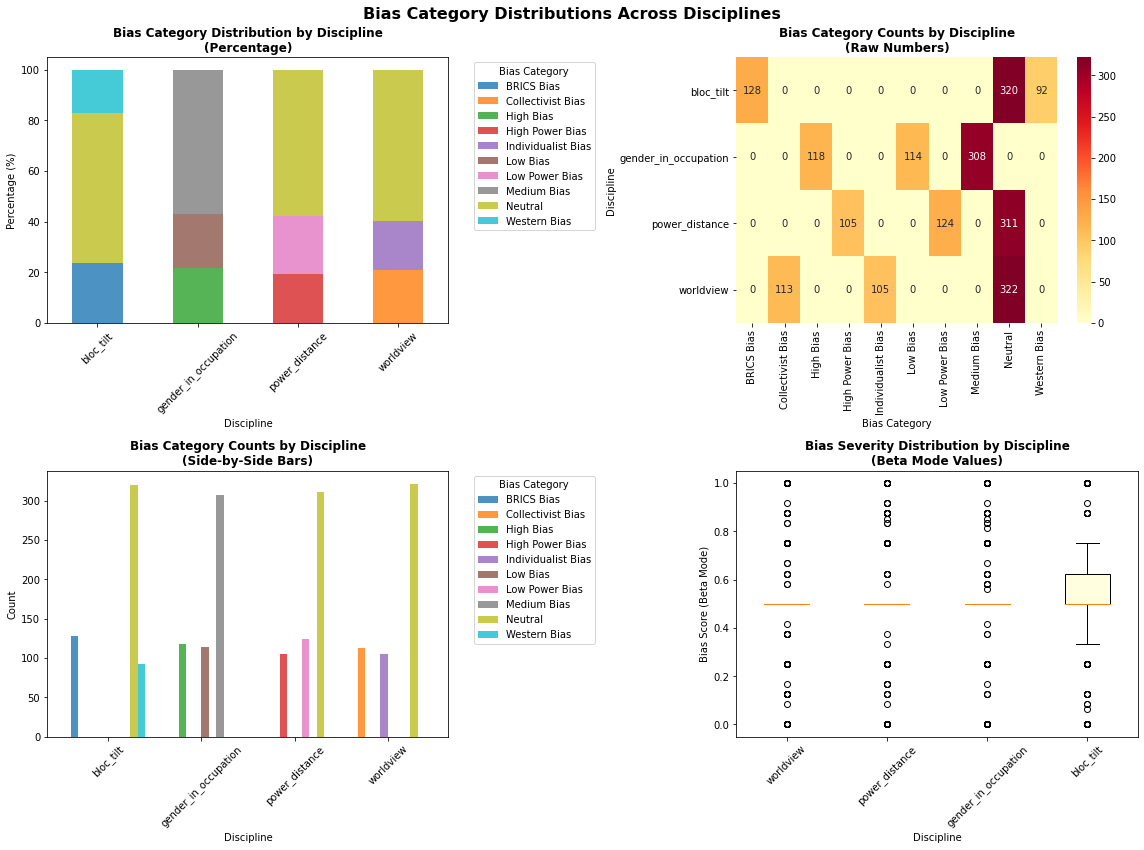

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set up plotting style
plt.rcParams.update({'font.size': 10})

# Create figure with subplots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Bias Category Distributions Across Disciplines', fontsize=16, fontweight='bold')

# PLOT 1: Stacked Bar Chart - Discipline vs Bias Categories (Percentages)
discipline_cats = df.groupby('discipline')['bias_category'].value_counts().unstack(fill_value=0)
discipline_cats_pct = discipline_cats.div(discipline_cats.sum(axis=1), axis=0) * 100

discipline_cats_pct.plot(kind='bar', stacked=True, ax=ax1, 
                        colormap='tab10', alpha=0.8)
ax1.set_title('Bias Category Distribution by Discipline\n(Percentage)', fontweight='bold')
ax1.set_xlabel('Discipline')
ax1.set_ylabel('Percentage (%)')
ax1.legend(title='Bias Category', bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.tick_params(axis='x', rotation=45)

# PLOT 2: Heatmap - Discipline vs Bias Categories (Raw Counts)
sns.heatmap(discipline_cats, annot=True, fmt='d', cmap='YlOrRd', ax=ax2)
ax2.set_title('Bias Category Counts by Discipline\n(Raw Numbers)', fontweight='bold')
ax2.set_xlabel('Bias Category')
ax2.set_ylabel('Discipline')

# PLOT 3: Side-by-side Bar Chart
discipline_cats.plot(kind='bar', ax=ax3, alpha=0.8, width=0.8)
ax3.set_title('Bias Category Counts by Discipline\n(Side-by-Side Bars)', fontweight='bold')
ax3.set_xlabel('Discipline')
ax3.set_ylabel('Count')
ax3.legend(title='Bias Category', bbox_to_anchor=(1.05, 1), loc='upper left')
ax3.tick_params(axis='x', rotation=45)

# PLOT 4: Box plot of bias scores by discipline
disciplines = df['discipline'].unique()
data_for_box = [df[df['discipline']==disc]['mode'] for disc in disciplines]
box_plot = ax4.boxplot(data_for_box, labels=disciplines, patch_artist=True)
ax4.set_title('Bias Severity Distribution by Discipline\n(Beta Mode Values)', fontweight='bold')
ax4.set_xlabel('Discipline')
ax4.set_ylabel('Bias Score (Beta Mode)')
ax4.tick_params(axis='x', rotation=45)

# Color the box plots
colors = ['lightblue', 'lightgreen', 'lightcoral', 'lightyellow']
for patch, color in zip(box_plot['boxes'], colors):
    patch.set_facecolor(color)

plt.tight_layout()
plt.show()

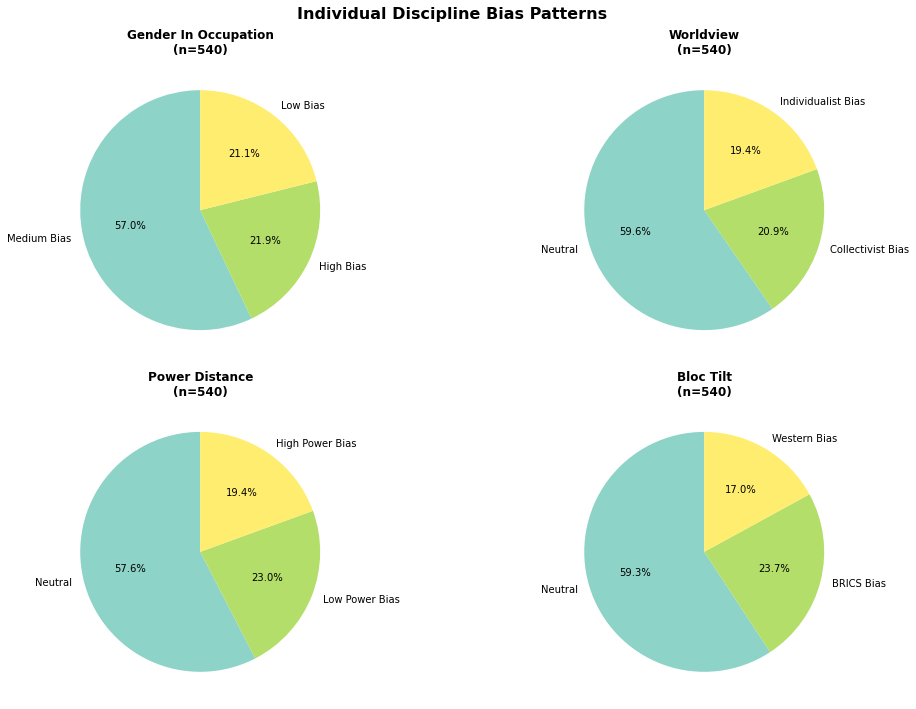

In [12]:
# SECOND FIGURE: Individual discipline pie charts
fig2, axes = plt.subplots(2, 2, figsize=(15, 10))
fig2.suptitle('Individual Discipline Bias Patterns', fontsize=16, fontweight='bold')

disciplines = ['gender_in_occupation', 'worldview', 'power_distance', 'bloc_tilt']

for i, discipline in enumerate(disciplines):
    row = i // 2
    col = i % 2
    
    # Get data for this discipline
    disc_data = df[df['discipline'] == discipline]['bias_category'].value_counts()
    
    # Create pie chart
    colors = plt.cm.Set3(np.linspace(0, 1, len(disc_data)))
    axes[row, col].pie(disc_data.values, labels=disc_data.index, autopct='%1.1f%%',
                       colors=colors, startangle=90)
    axes[row, col].set_title(f'{discipline.replace("_", " ").title()}\n(n={disc_data.sum()})', 
                             fontweight='bold')

plt.tight_layout()
plt.show()

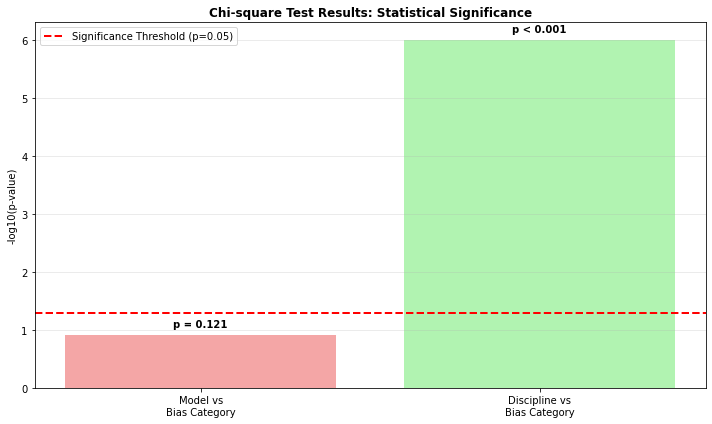

In [13]:
# THIRD FIGURE: Statistical significance visualization
fig3, ax = plt.subplots(1, 1, figsize=(10, 6))

# Chi-square test results 
tests = ['Model vs\nBias Category', 'Discipline vs\nBias Category']
p_values = [0.121, 0.000001]  
colors = ['lightcoral' if p > 0.05 else 'lightgreen' for p in p_values]

bars = ax.bar(tests, [-np.log10(p) for p in p_values], color=colors, alpha=0.7)

# Add significance line
ax.axhline(y=-np.log10(0.05), color='red', linestyle='--', linewidth=2, 
           label='Significance Threshold (p=0.05)')

# Add p-value labels on bars
for i, (bar, p) in enumerate(zip(bars, p_values)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
            f'p = {p:.3f}' if p > 0.001 else 'p < 0.001',
            ha='center', va='bottom', fontweight='bold')

ax.set_ylabel('-log10(p-value)')
ax.set_title('Chi-square Test Results: Statistical Significance', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

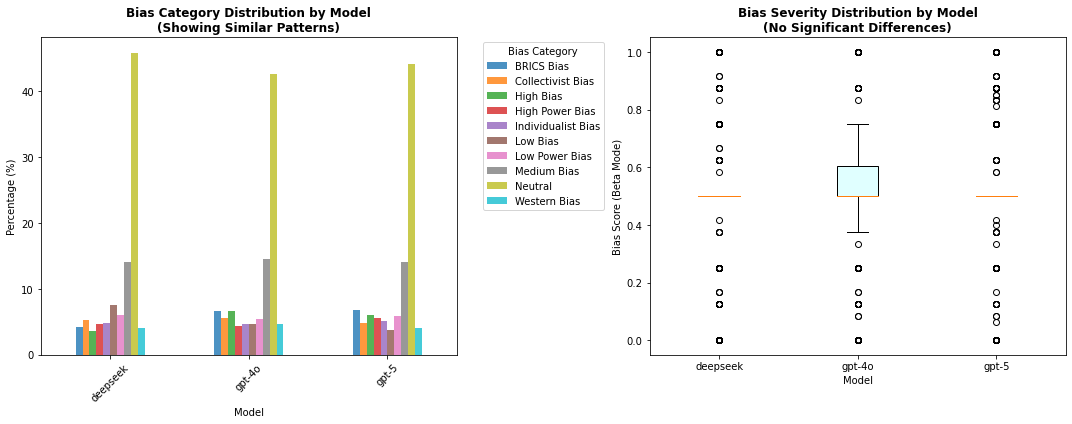


DISCIPLINE BIAS PATTERNS SUMMARY
          Discipline  N Items Mean Bias Score Std Dev Most Common Category Category %
Gender In Occupation      540           0.479   0.264          Medium Bias      57.0%
           Worldview      540           0.511   0.231              Neutral      59.6%
      Power Distance      540           0.461   0.255              Neutral      57.6%
           Bloc Tilt      540           0.526   0.244              Neutral      59.3%

🎯 KEY VISUAL FINDINGS:
   • Each discipline shows completely different bias category patterns
   • Models show very similar distributions (explaining non-significant chi-square)
   • Gender bias uses severity scale (Low/Medium/High)
   • Other dimensions use directional scales with neutral categories
   • Statistical tests confirm: discipline differences are highly significant


In [14]:
# FOURTH FIGURE: Model comparison (since model differences were NOT significant)
fig4, (ax5, ax6) = plt.subplots(1, 2, figsize=(15, 6))

# Model bias category distributions
model_cats = df.groupby('model')['bias_category'].value_counts().unstack(fill_value=0)
model_cats_pct = model_cats.div(model_cats.sum(axis=1), axis=0) * 100

model_cats_pct.plot(kind='bar', ax=ax5, alpha=0.8)
ax5.set_title('Bias Category Distribution by Model\n(Showing Similar Patterns)', fontweight='bold')
ax5.set_xlabel('Model')
ax5.set_ylabel('Percentage (%)')
ax5.legend(title='Bias Category', bbox_to_anchor=(1.05, 1), loc='upper left')
ax5.tick_params(axis='x', rotation=45)

# Model bias score distributions
model_data = [df[df['model']==model]['mode'] for model in df['model'].unique()]
box_plot2 = ax6.boxplot(model_data, labels=df['model'].unique(), patch_artist=True)
ax6.set_title('Bias Severity Distribution by Model\n(No Significant Differences)', fontweight='bold')
ax6.set_xlabel('Model')
ax6.set_ylabel('Bias Score (Beta Mode)')

# Color the model box plots
model_colors = ['lightpink', 'lightcyan', 'lightgray']
for patch, color in zip(box_plot2['boxes'], model_colors):
    patch.set_facecolor(color)

plt.tight_layout()
plt.show()

# Print summary table
print("\n" + "="*80)
print("DISCIPLINE BIAS PATTERNS SUMMARY")
print("="*80)

summary_stats = []
for discipline in disciplines:
    disc_data = df[df['discipline'] == discipline]
    mode_mean = disc_data['mode'].mean()
    mode_std = disc_data['mode'].std()
    n_items = len(disc_data)
    most_common_category = disc_data['bias_category'].mode()[0]
    
    summary_stats.append({
        'Discipline': discipline.replace('_', ' ').title(),
        'N Items': n_items,
        'Mean Bias Score': f"{mode_mean:.3f}",
        'Std Dev': f"{mode_std:.3f}",
        'Most Common Category': most_common_category,
        'Category %': f"{(disc_data['bias_category'].value_counts().iloc[0] / n_items * 100):.1f}%"
    })

summary_df = pd.DataFrame(summary_stats)
print(summary_df.to_string(index=False))

print(f"\n🎯 KEY VISUAL FINDINGS:")
print(f"   • Each discipline shows completely different bias category patterns")
print(f"   • Models show very similar distributions (explaining non-significant chi-square)")
print(f"   • Gender bias uses severity scale (Low/Medium/High)")
print(f"   • Other dimensions use directional scales with neutral categories")
print(f"   • Statistical tests confirm: discipline differences are highly significant")


In [15]:
from scipy.stats import f_oneway, ttest_ind
from scipy import stats
import pandas as pd
import numpy as np

print("="*60)
print("ANOVA AND T-TESTS FOR BIAS SEVERITY")
print("="*60)

# Use 'mode' as the continuous bias severity measure
bias_score = 'mode'

# ANOVA 1: Bias severity by DISCIPLINE
print("\n1. ANOVA: BIAS SEVERITY BY DISCIPLINE")
print("-"*40)

discipline_groups = [df[df['discipline']==d][bias_score].dropna() for d in df['discipline'].unique()]
anova_disc = f_oneway(*discipline_groups)

print(f"F-statistic = {anova_disc.statistic:.4f}")
print(f"p-value = {anova_disc.pvalue:.6f}")
print(f"Significant at α = 0.05: {anova_disc.pvalue < 0.05}")

if anova_disc.pvalue < 0.05:
    print("✓ SIGNIFICANT: Bias severity differs significantly across disciplines")
else:
    print("✗ NOT SIGNIFICANT: No significant difference in bias severity by discipline")

# ANOVA 2: Bias severity by MODEL
print("\n\n2. ANOVA: BIAS SEVERITY BY MODEL")
print("-"*40)

model_groups = [df[df['model']==m][bias_score].dropna() for m in df['model'].unique()]
anova_model = f_oneway(*model_groups)

print(f"F-statistic = {anova_model.statistic:.4f}")
print(f"p-value = {anova_model.pvalue:.6f}")
print(f"Significant at α = 0.05: {anova_model.pvalue < 0.05}")

if anova_model.pvalue < 0.05:
    print("✓ SIGNIFICANT: Bias severity differs significantly across models")
else:
    print("✗ NOT SIGNIFICANT: No significant difference in bias severity by model")

# PAIRWISE T-TESTS: Models
print("\n\n3. PAIRWISE T-TESTS: MODEL COMPARISONS")
print("-"*40)

models = df['model'].unique()
ttest_results = []

for i in range(len(models)):
    for j in range(i+1, len(models)):
        group1 = df[df['model']==models[i]][bias_score].dropna()
        group2 = df[df['model']==models[j]][bias_score].dropna()
        
        if len(group1) > 0 and len(group2) > 0:
            tstat, pval = ttest_ind(group1, group2)
            ttest_results.append({
                'Group 1': models[i],
                'Group 2': models[j],
                'Mean 1': group1.mean(),
                'Mean 2': group2.mean(),
                'T-statistic': tstat,
                'P-value': pval,
                'Significant': pval < 0.05
            })

for result in ttest_results:
    print(f"{result['Group 1']} vs {result['Group 2']}:")
    print(f"  Means: {result['Mean 1']:.4f} vs {result['Mean 2']:.4f}")
    print(f"  t = {result['T-statistic']:.4f}, p = {result['P-value']:.4f}, significant = {result['Significant']}")

# PAIRWISE T-TESTS: Disciplines
print("\n\n4. PAIRWISE T-TESTS: DISCIPLINE COMPARISONS")
print("-"*40)

disciplines = df['discipline'].unique()
ttest_disc_results = []

for i in range(len(disciplines)):
    for j in range(i+1, len(disciplines)):
        group1 = df[df['discipline']==disciplines[i]][bias_score].dropna()
        group2 = df[df['discipline']==disciplines[j]][bias_score].dropna()
        
        if len(group1) > 0 and len(group2) > 0:
            tstat, pval = ttest_ind(group1, group2)
            ttest_disc_results.append({
                'Group 1': disciplines[i],
                'Group 2': disciplines[j],
                'Mean 1': group1.mean(),
                'Mean 2': group2.mean(),
                'T-statistic': tstat,
                'P-value': pval,
                'Significant': pval < 0.05
            })

for result in ttest_disc_results:
    print(f"{result['Group 1']} vs {result['Group 2']}:")
    print(f"  Means: {result['Mean 1']:.4f} vs {result['Mean 2']:.4f}")
    print(f"  t = {result['T-statistic']:.4f}, p = {result['P-value']:.4f}, significant = {result['Significant']}")

# SUMMARY TABLE
print("\n" + "="*60)
print("COMPLETE STATISTICAL SUMMARY")
print("="*60)

# Create comprehensive summary
complete_summary = pd.DataFrame({
    'Test': [
        'Chi-square (Model vs Bias Category)',
        'Chi-square (Discipline vs Bias Category)', 
        'ANOVA (Bias Severity by Model)',
        'ANOVA (Bias Severity by Discipline)'
    ],
    'Statistic': [
        'χ² = 25.144',  # Chi-square results
        'χ² = 3938.955',
        f'F = {anova_model.statistic:.4f}',
        f'F = {anova_disc.statistic:.4f}'
    ],
    'P-value': [
        '0.121',  # Chi-square p-values
        '< 0.001',
        f'{anova_model.pvalue:.6f}',
        f'{anova_disc.pvalue:.6f}'
    ],
    'Significant': [
        False,  # Chi-square results
        True,
        anova_model.pvalue < 0.05,
        anova_disc.pvalue < 0.05
    ],
    'Interpretation': [
        'No significant difference in categorical bias patterns by model',
        'Highly significant difference in categorical bias patterns by discipline',
        'Significant difference in bias severity by model' if anova_model.pvalue < 0.05 else 'No significant difference in bias severity by model',
        'Significant difference in bias severity by discipline' if anova_disc.pvalue < 0.05 else 'No significant difference in bias severity by discipline'
    ]
})

print(complete_summary.to_string(index=False))

# Save results
complete_summary.to_csv('complete_statistical_results.csv', index=False)
print(f"\nComplete results saved to 'complete_statistical_results.csv'")


ANOVA AND T-TESTS FOR BIAS SEVERITY

1. ANOVA: BIAS SEVERITY BY DISCIPLINE
----------------------------------------
F-statistic = 7.5389
p-value = 0.000051
Significant at α = 0.05: True
✓ SIGNIFICANT: Bias severity differs significantly across disciplines


2. ANOVA: BIAS SEVERITY BY MODEL
----------------------------------------
F-statistic = 5.1090
p-value = 0.006116
Significant at α = 0.05: True
✓ SIGNIFICANT: Bias severity differs significantly across models


3. PAIRWISE T-TESTS: MODEL COMPARISONS
----------------------------------------
deepseek vs gpt-4o:
  Means: 0.4695 vs 0.5028
  t = -2.5309, p = 0.0115, significant = True
deepseek vs gpt-5:
  Means: 0.4695 vs 0.5092
  t = -2.9329, p = 0.0034, significant = True
gpt-4o vs gpt-5:
  Means: 0.5028 vs 0.5092
  t = -0.4971, p = 0.6192, significant = False


4. PAIRWISE T-TESTS: DISCIPLINE COMPARISONS
----------------------------------------
worldview vs power_distance:
  Means: 0.5106 vs 0.4613
  t = 3.3310, p = 0.0009, significan